# ⚽ Finding Player Similarity

This notebook trains a **player embedding model** using Graph Neural Networks and Temporal Transformers to learn dense representations of football players based on their on-ball actions.

## Model Architecture
| Component | Description |
|-----------|-------------|
| **Graph Encoder** | 3-layer GAT with edge features (distance, team, relative position) |
| **Temporal Transformer** | 2-layer transformer with Time2Vec positional encoding |
| **Hierarchical Pooling** | Multi-scale temporal aggregation (actions → sequences → player) |
| **Contrastive Learning** | InfoNCE loss to pull same-player embeddings together |

## Training Data: 8 Male Competitions with StatsBomb 360
- Bundesliga 2023/24
- World Cup 2022  
- La Liga 2020/21
- Ligue 1 2022/23, 2021/22
- MLS 2023
- UEFA Euro 2024, 2020

**Contact:** Armen Bzdikian (bzdikiana11@gmail.com)

## 1️⃣ Setup & Imports

In [20]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, os.path.abspath('.'))

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from collections import defaultdict
from typing import List, Dict, Tuple, Optional
from tqdm.auto import tqdm
import random

# === Import ALL production modules ===
# Datasets
from src.datasets.adapters.stats360_adapter import Stats360Adapter
from src.datasets.builders.event_graph_builder import EventGraphBuilder, EventGraphConfig
from src.datasets.schema_contracts import EventRecord, PlayerRef, MatchContext, POSITION_CATEGORIES

# Models - Now with enhanced features!
from src.models.encoders.event_graph_encoder import EventGraphEncoder
from src.models.encoders.temporal_transformer import TemporalTransformerEncoder
from src.models.encoders.fusion_heads import ProjectionHead

# Training - Multi-task loss!
from src.training.losses import InfoNCELoss, MultiTaskLoss

# Retrieval
from src.retrieval.similarity import CosineSimilarity

# Set device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("✅ All modules imported!")
print(f"🔧 PyTorch: {torch.__version__}")
print(f"💻 Device: {DEVICE}")

✅ All modules imported!
🔧 PyTorch: 2.10.0+cpu
💻 Device: cpu


## 2️⃣ Configuration

In [ ]:
# === ENHANCED CONFIGURATION ===

# =====================================================
# ALL MALE COMPETITIONS WITH 360 DATA (No Female)
# =====================================================
COMPETITIONS_360 = [
    # Bundesliga
    {"name": "Bundesliga 2023/24", "competition_id": 9, "season_id": 281},
    
    # FIFA World Cup (Men)
    {"name": "FIFA World Cup 2022", "competition_id": 43, "season_id": 106},
    
    # La Liga
    {"name": "La Liga 2020/21", "competition_id": 11, "season_id": 90},
    
    # Ligue 1
    {"name": "Ligue 1 2022/23", "competition_id": 7, "season_id": 235},
    {"name": "Ligue 1 2021/22", "competition_id": 7, "season_id": 108},
    
    # Major League Soccer
    {"name": "MLS 2023", "competition_id": 44, "season_id": 107},
    
    # UEFA Euro (Men)
    {"name": "UEFA Euro 2024", "competition_id": 55, "season_id": 282},
    {"name": "UEFA Euro 2020", "competition_id": 55, "season_id": 43},
]

# NOTE: Excluded female competitions:
# - UEFA Women's Euro 2025 (comp_id=53, season_id=315)
# - UEFA Women's Euro 2022 (comp_id=53, season_id=106)
# - Women's World Cup 2023 (comp_id=72, season_id=107)

MAX_MATCHES_PER_COMPETITION = None  # Load ALL matches from each competition

# Model Architecture
HIDDEN_DIM = 128
EMBEDDING_DIM = 64

# NEW FEATURES - Enable/Disable
USE_EDGE_FEATURES = True        # Distance, same_team between players
USE_TIME2VEC = True             # Learnable continuous time
USE_HIERARCHICAL_POOLING = True # Multi-scale temporal pooling
USE_MULTITASK = True            # Multi-task learning

# =====================================================
# AUXILIARY TASK CONFIGURATION
# =====================================================
# Next Action Prediction: "What will this player do next?"
# - MUCH better than position prediction
# - Captures decision-making style (Messi → dribble, Van Dijk → clear)
USE_NEXT_ACTION_PREDICTION = True   # RECOMMENDED!
ACTION_LOSS_WEIGHT = 0.1            # Weight for action prediction

# Position prediction (less useful - keeping option but disabled)
USE_POSITION_PREDICTION = False     # Disabled - doesn't capture playing style
POSITION_LOSS_WEIGHT = 0.01         # Reduced from 0.1

# Training - INCREASED EPOCHS
NUM_EPOCHS = 50                 # Increased from 10 to 50
STEPS_PER_EPOCH = 100
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
TEMPERATURE = 0.07

# Import event type categories for next action prediction
from src.datasets.schema_contracts import EVENT_TYPE_CATEGORIES
N_ACTION_TYPES = len(EVENT_TYPE_CATEGORIES) + 1  # +1 for unknown

print("📋 Configuration:")
print(f"   Competitions: {len(COMPETITIONS_360)} male competitions with 360 data")
print(f"   Max Matches: {'ALL' if MAX_MATCHES_PER_COMPETITION is None else MAX_MATCHES_PER_COMPETITION}")
print(f"")
print(f"   Edge Features: {USE_EDGE_FEATURES}")
print(f"   Time2Vec: {USE_TIME2VEC}")
print(f"   Hierarchical Pooling: {USE_HIERARCHICAL_POOLING}")
print(f"   Multi-Task Learning: {USE_MULTITASK}")
print(f"")
print(f"   🎯 Next Action Prediction: {USE_NEXT_ACTION_PREDICTION} (weight={ACTION_LOSS_WEIGHT})")
print(f"   📍 Position Prediction: {USE_POSITION_PREDICTION} (weight={POSITION_LOSS_WEIGHT})")
print(f"")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Steps per Epoch: {STEPS_PER_EPOCH}")
print(f"\n   Action types to predict: {N_ACTION_TYPES}")

📋 Configuration:
   Competitions: 8 male competitions with 360 data
   Max Matches: ALL

   Edge Features: True
   Time2Vec: True
   Hierarchical Pooling: True
   Multi-Task Learning: True

   Epochs: 50
   Steps per Epoch: 100


## 3️⃣ Load Data

In [22]:
# Initialize adapter
adapter = Stats360Adapter(verify_ssl=False)

# Store all events and player info
all_events = []
all_players_info = {}
events_by_match = defaultdict(list)

print("Loading data from competitions...\n")

for comp in COMPETITIONS_360:
    print(f"📥 Loading {comp['name']}...")
    
    try:
        # Load matches
        matches = adapter.load_matches(comp['competition_id'], comp['season_id'])
        n_matches = min(len(matches), MAX_MATCHES_PER_COMPETITION) if MAX_MATCHES_PER_COMPETITION else len(matches)
        
        print(f"   Found {len(matches)} matches, loading {n_matches}...")
        
        # Load events
        events = adapter.load_competition_events(
            comp['competition_id'], 
            comp['season_id'],
            max_matches=MAX_MATCHES_PER_COMPETITION,
            verbose=False
        )
        
        # Group by match
        for event in events:
            events_by_match[event.match_id].append(event)
        
        # Get player info
        players = adapter.get_unique_players(events)
        for pid, info in players.items():
            if pid not in all_players_info:
                all_players_info[pid] = info
            else:
                all_players_info[pid]['n_events'] += info['n_events']
                all_players_info[pid]['n_events_as_actor'] += info['n_events_as_actor']
        
        all_events.extend(events)
        print(f"   ✓ {len(events):,} events, {len(players)} players")
        
    except Exception as e:
        print(f"   ⚠️ Error: {e}")

print(f"\n" + "="*50)
print(f"📈 Total Events: {len(all_events):,}")
print(f"👥 Total Unique Players: {len(all_players_info)}")
print(f"⚽ Total Matches: {len(events_by_match)}")

Loading data from competitions...

📥 Loading Bundesliga 2023/24...
   Found 34 matches, loading 34...
   ✓ 137,070 events, 372 players
📥 Loading FIFA World Cup 2022...
   Found 64 matches, loading 64...
   ✓ 233,217 events, 680 players
📥 Loading La Liga 2020/21...
   Found 35 matches, loading 35...
   ✓ 138,364 events, 383 players
📥 Loading Ligue 1 2022/23...
   Found 32 matches, loading 32...
   ✓ 128,831 events, 387 players
📥 Loading Ligue 1 2021/22...
   Found 26 matches, loading 26...
   ✓ 101,251 events, 327 players
📥 Loading MLS 2023...
   Found 6 matches, loading 6...
   ✓ 21,662 events, 118 players
📥 Loading UEFA Euro 2024...
   Found 51 matches, loading 51...
   ✓ 186,685 events, 496 players
📥 Loading UEFA Euro 2020...
   Found 51 matches, loading 51...
   ✓ 191,605 events, 490 players

📈 Total Events: 1,138,685
👥 Total Unique Players: 2370
⚽ Total Matches: 299


## 4️⃣ Build Event Graphs (WITH Edge Features)

In [23]:
# Configure graph builder - NOW WITH EDGE FEATURES!
graph_config = EventGraphConfig(
    node_feature_dim=32,
    use_position_encoding=True,
    use_location_features=True,
    use_role_features=True,
    use_edge_features=USE_EDGE_FEATURES,  # NEW!
    max_players_per_event=22,
)

graph_builder = EventGraphBuilder(config=graph_config)

print(f"✅ Graph Builder configured")
print(f"   Node features: {graph_builder._node_feature_dim} dimensions")
print(f"   Edge features: {graph_builder._edge_feature_dim} dimensions")
print(f"   Context features: {graph_builder._context_feature_dim} dimensions")

✅ Graph Builder configured
   Node features: 66 dimensions
   Edge features: 4 dimensions
   Context features: 8 dimensions


In [ ]:
# Build graphs for all events
print(f"Building graphs for {len(all_events):,} events...")

event_graphs = []
event_metadata = []

for event in tqdm(all_events, desc="Building graphs"):
    try:
        graph = graph_builder.build_graph(event)
        event_graphs.append(graph)
        
        # Track metadata for training
        actor_id = graph.player_ids[0] if graph.player_ids else -1
        
        # Get position index for multi-task learning
        position_idx = 0  # Default unknown
        if event.actor and event.actor.position:
            pos = event.actor.position
            if pos in POSITION_CATEGORIES:
                position_idx = POSITION_CATEGORIES.index(pos)
        
        # Get event type index for NEXT ACTION PREDICTION
        event_type_idx = N_ACTION_TYPES - 1  # Default to unknown
        if event.event_type in EVENT_TYPE_CATEGORIES:
            event_type_idx = EVENT_TYPE_CATEGORIES.index(event.event_type)
        
        event_metadata.append({
            'match_id': event.match_id,
            'player_id': actor_id,
            'event_type': event.event_type,
            'event_type_idx': event_type_idx,  # NEW: for next action prediction
            'position_idx': position_idx,
        })
    except Exception as e:
        continue

print(f"\n✅ Built {len(event_graphs):,} event graphs")
if USE_EDGE_FEATURES:
    print(f"   Each graph has edge features: {event_graphs[0].edge_features.shape}")
print(f"   Event types tracked: {len(EVENT_TYPE_CATEGORIES)} categories")

Building graphs for 1,138,685 events...


Building graphs: 100%|██████████| 1138685/1138685 [01:34<00:00, 12082.66it/s]


✅ Built 1,138,685 event graphs
   Each graph has edge features: torch.Size([22, 22, 4])


## 5️⃣ Initialize Enhanced Models

In [25]:
# Event Graph Encoder - NOW WITH EDGE FEATURES!
event_encoder = EventGraphEncoder(
    node_input_dim=graph_builder._node_feature_dim,
    context_dim=graph_builder._context_feature_dim,
    hidden_dim=HIDDEN_DIM,
    output_dim=HIDDEN_DIM,
    n_layers=3,
    n_heads=4,
    dropout=0.1,
    pooling="attention",
    use_edge_features=USE_EDGE_FEATURES,  # NEW!
    edge_feature_dim=graph_builder._edge_feature_dim,
).to(DEVICE)

# Temporal Transformer - NOW WITH TIME2VEC & HIERARCHICAL POOLING!
temporal_encoder = TemporalTransformerEncoder(
    input_dim=HIDDEN_DIM,
    hidden_dim=HIDDEN_DIM * 2,
    output_dim=HIDDEN_DIM,
    n_layers=2,
    n_heads=4,
    dropout=0.1,
    max_length=256,
    pooling="hierarchical" if USE_HIERARCHICAL_POOLING else "mean",  # NEW!
    use_time2vec=USE_TIME2VEC,  # NEW!
).to(DEVICE)

# Projection Head
projection_head = ProjectionHead(
    input_dim=HIDDEN_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=EMBEDDING_DIM,
    n_layers=2,
    normalize=True
).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for m in [event_encoder, temporal_encoder, projection_head] for p in m.parameters())
trainable_params = sum(p.numel() for m in [event_encoder, temporal_encoder, projection_head] for p in m.parameters() if p.requires_grad)

print(f"✅ Enhanced Models initialized on {DEVICE}")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"\n📊 Model Features:")
print(f"   • Edge Features: {event_encoder.use_edge_features}")
print(f"   • Pooling Type: {temporal_encoder.pooling}")

✅ Enhanced Models initialized on cpu
   Total parameters: 3,001,279
   Trainable parameters: 3,001,279

📊 Model Features:
   • Edge Features: True
   • Pooling Type: hierarchical


## 6️⃣ Encode Events with Edge Features

In [26]:
# Encode all events through the GNN (now with edge features!)
BATCH_SIZE_ENCODE = 64

event_encoder.eval()

print(f"Encoding {len(event_graphs):,} events with edge features...")

all_event_embeddings = []

with torch.no_grad():
    for i in tqdm(range(0, len(event_graphs), BATCH_SIZE_ENCODE), desc="Encoding"):
        batch_graphs = event_graphs[i:i+BATCH_SIZE_ENCODE]
        batch = graph_builder.batch_graphs(batch_graphs)
        batch = batch.to(DEVICE)
        
        # Forward with edge features!
        output = event_encoder(
            batch.node_features,
            batch.context_features,
            batch.attention_mask,
            edge_features=batch.edge_features,  # NEW!
            node_mask=batch.batch_mask
        )
        
        all_event_embeddings.append(output['event_embedding'].cpu())

all_event_embeddings = torch.cat(all_event_embeddings, dim=0)
print(f"\n✅ Event embeddings: {all_event_embeddings.shape}")

Encoding 1,138,685 events with edge features...


Encoding: 100%|██████████| 17792/17792 [12:57<00:00, 22.89it/s] 



✅ Event embeddings: torch.Size([1138685, 128])


## 7️⃣ Group Events by Player

In [27]:
# Group events by (player_id, match_id)
player_match_events = defaultdict(lambda: defaultdict(list))
player_positions = {}  # Track most common position for each player

for idx, meta in enumerate(event_metadata):
    player_id = meta['player_id']
    match_id = meta['match_id']
    position_idx = meta['position_idx']
    
    if player_id > 0:
        player_match_events[player_id][match_id].append(idx)
        
        # Track positions
        if player_id not in player_positions:
            player_positions[player_id] = defaultdict(int)
        player_positions[player_id][position_idx] += 1

# Get most common position for each player
player_primary_position = {}
for pid, pos_counts in player_positions.items():
    most_common = max(pos_counts.items(), key=lambda x: x[1])[0]
    player_primary_position[pid] = most_common

# Filter players
MIN_MATCHES = 2
MIN_EVENTS_PER_MATCH = 10

valid_players = {}
for player_id, matches in player_match_events.items():
    valid_matches = {m: events for m, events in matches.items() if len(events) >= MIN_EVENTS_PER_MATCH}
    if len(valid_matches) >= MIN_MATCHES:
        valid_players[player_id] = valid_matches

print(f"Players with >= {MIN_MATCHES} matches: {len(valid_players)}")
print(f"Players with position labels: {len(player_primary_position)}")

Players with >= 2 matches: 1570
Players with position labels: 2370


## 8️⃣ Create Training Batches (With Position Labels)

In [ ]:
def create_training_batch(
    valid_players: Dict,
    event_embeddings: torch.Tensor,
    event_metadata: List,
    player_positions: Dict,
    batch_size: int = 32,
    max_seq_len: int = 64,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Create a batch for training with NEXT ACTION labels.
    
    Next Action Prediction: Given a player's sequence of actions,
    predict what their NEXT action will be. This captures:
    - Messi: likely to dribble or shoot
    - Van Dijk: likely to clear or make long pass
    - Busquets: likely to make short pass or recover ball
    
    Returns:
        sequences: [B, L, D] - event embeddings sequence
        time_positions: [B, L] - normalized time positions
        masks: [B, L] - attention masks
        labels: [B] - player IDs for contrastive loss
        next_action_labels: [B] - the NEXT action type index
        position_labels: [B] - position indices (optional)
    """
    player_ids = list(valid_players.keys())
    sampled_players = random.choices(player_ids, k=batch_size)
    
    sequences = []
    labels = []
    next_action_labels = []
    position_labels = []
    
    for player_id in sampled_players:
        matches = valid_players[player_id]
        match_id = random.choice(list(matches.keys()))
        event_indices = matches[match_id]
        
        # Sort by index to maintain temporal order
        event_indices = sorted(event_indices)
        
        # We need at least 2 events to predict "next action"
        if len(event_indices) < 2:
            # Use padding
            seq = torch.zeros(max_seq_len, event_embeddings.shape[1])
            sequences.append(seq)
            labels.append(player_id)
            next_action_labels.append(N_ACTION_TYPES - 1)  # Unknown
            position_labels.append(player_positions.get(player_id, 0))
            continue
        
        # Sample a window of events, keeping one as the "next action" to predict
        if len(event_indices) > max_seq_len + 1:
            start_idx = random.randint(0, len(event_indices) - max_seq_len - 1)
            context_indices = event_indices[start_idx:start_idx + max_seq_len]
            next_action_idx = event_indices[start_idx + max_seq_len]
        else:
            # Use all but the last as context, last as target
            context_indices = event_indices[:-1]
            next_action_idx = event_indices[-1]
        
        # Get the next action type
        next_action_type = event_metadata[next_action_idx]['event_type_idx']
        
        # Build sequence
        seq = event_embeddings[context_indices]
        seq_len = seq.shape[0]
        
        if seq_len < max_seq_len:
            padding = torch.zeros(max_seq_len - seq_len, seq.shape[1])
            seq = torch.cat([seq, padding], dim=0)
        
        sequences.append(seq)
        labels.append(player_id)
        next_action_labels.append(next_action_type)
        position_labels.append(player_positions.get(player_id, 0))
    
    batch_sequences = torch.stack(sequences)
    batch_labels = torch.tensor(labels)
    batch_next_actions = torch.tensor(next_action_labels, dtype=torch.long)
    batch_positions = torch.tensor(position_labels)
    batch_masks = torch.ones(batch_size, max_seq_len, dtype=torch.bool)
    time_positions = torch.linspace(0, 1, max_seq_len).unsqueeze(0).expand(batch_size, -1)
    
    return batch_sequences, time_positions, batch_masks, batch_labels, batch_next_actions, batch_positions

print("✅ Training batch creator ready")
print("   🎯 Now returns NEXT ACTION labels for prediction!")
print(f"   Action types: {EVENT_TYPE_CATEGORIES[:5]}... ({len(EVENT_TYPE_CATEGORIES)} total)")

✅ Training batch creator ready (with position labels for multi-task)


## 9️⃣ Setup Multi-Task Training

In [ ]:
# Initialize loss function with NEXT ACTION PREDICTION
if USE_MULTITASK:
    # Multi-task loss: InfoNCE + Next Action Prediction
    loss_fn = MultiTaskLoss(
        temperature=TEMPERATURE,
        # Next Action Prediction - RECOMMENDED
        action_weight=ACTION_LOSS_WEIGHT,
        use_action_loss=USE_NEXT_ACTION_PREDICTION,
        n_action_types=N_ACTION_TYPES,
        # Position Prediction - disabled by default
        position_weight=POSITION_LOSS_WEIGHT,
        use_position_loss=USE_POSITION_PREDICTION,
        n_positions=len(POSITION_CATEGORIES) + 1,
        embedding_dim=EMBEDDING_DIM,
    ).to(DEVICE)
    
    # Add auxiliary heads to optimizer
    all_params = (
        list(temporal_encoder.parameters()) + 
        list(projection_head.parameters())
    )
    
    if USE_NEXT_ACTION_PREDICTION:
        all_params += list(loss_fn.action_head.parameters())
        print("   🎯 Action prediction head added")
    
    if USE_POSITION_PREDICTION:
        all_params += list(loss_fn.position_head.parameters())
        print("   📍 Position prediction head added")
else:
    loss_fn = InfoNCELoss(temperature=TEMPERATURE)
    all_params = list(temporal_encoder.parameters()) + list(projection_head.parameters())

# Optimizer
optimizer = torch.optim.AdamW(all_params, lr=LEARNING_RATE, weight_decay=0.01)

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=NUM_EPOCHS * STEPS_PER_EPOCH
)

print("\n✅ Training setup complete")
print(f"   Loss Type: {'MultiTask' if USE_MULTITASK else 'InfoNCE only'}")
if USE_MULTITASK:
    print(f"   ├── InfoNCE contrastive loss (main)")
    if USE_NEXT_ACTION_PREDICTION:
        print(f"   ├── Next Action Prediction (weight={ACTION_LOSS_WEIGHT})")
    if USE_POSITION_PREDICTION:
        print(f"   └── Position Prediction (weight={POSITION_LOSS_WEIGHT})")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Steps per epoch: {STEPS_PER_EPOCH}")

✅ Training setup complete
   Loss Type: MultiTask (InfoNCE + Position)
   Epochs: 50
   Steps per epoch: 100


## 🔟 Training Loop

In [ ]:
# Training loop with NEXT ACTION PREDICTION
temporal_encoder.train()
projection_head.train()

# Track multiple metrics
loss_history = []
contrastive_loss_history = []
action_loss_history = []      # NEW: action prediction loss
action_acc_history = []       # NEW: action prediction accuracy
position_loss_history = []
position_acc_history = []
embedding_std_history = []
avg_positive_sim_history = []
avg_negative_sim_history = []

print("\n" + "="*70)
print("🏋️ TRAINING WITH NEXT ACTION PREDICTION")
print("="*70)
print("\n📊 Metrics being tracked:")
print("   • Total Loss (InfoNCE + Action Prediction)")
print("   • Contrastive Loss (pulling same player together)")
print("   • 🎯 Action Accuracy (can we predict what player does next?)")
print("   • Embedding STD (to detect collapse)")
print("   • Positive/Negative Similarity Gap (is learning happening?)")
print("="*70 + "\n")

for epoch in range(NUM_EPOCHS):
    epoch_losses = []
    epoch_contrastive_losses = []
    epoch_action_losses = []
    epoch_action_accs = []
    epoch_position_losses = []
    epoch_pos_accs = []
    epoch_pos_sims = []
    epoch_neg_sims = []
    epoch_emb_stds = []
    
    pbar = tqdm(range(STEPS_PER_EPOCH), desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    for step in pbar:
        # Create batch with NEXT ACTION labels
        sequences, time_pos, masks, labels, next_action_labels, position_labels = create_training_batch(
            valid_players, all_event_embeddings, event_metadata, player_primary_position, BATCH_SIZE
        )
        
        sequences = sequences.to(DEVICE)
        time_pos = time_pos.to(DEVICE)
        masks = masks.to(DEVICE)
        labels = labels.to(DEVICE)
        next_action_labels = next_action_labels.to(DEVICE)
        position_labels = position_labels.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Forward pass
        temp_output = temporal_encoder(sequences, time_pos, masks)
        embeddings = projection_head(temp_output['player_embedding'])
        
        # Compute loss with NEXT ACTION prediction
        if USE_MULTITASK:
            loss_dict = loss_fn(
                embeddings, 
                labels, 
                next_action_labels=next_action_labels,
                position_labels=position_labels if USE_POSITION_PREDICTION else None
            )
            loss = loss_dict['total_loss']
            
            # Track action prediction
            if 'action_accuracy' in loss_dict:
                epoch_action_accs.append(loss_dict['action_accuracy'].item())
            if 'action_loss' in loss_dict:
                epoch_action_losses.append(loss_dict['action_loss'].item())
            
            # Track position prediction (if enabled)
            if 'position_accuracy' in loss_dict:
                epoch_pos_accs.append(loss_dict['position_accuracy'].item())
            if 'position_loss' in loss_dict:
                epoch_position_losses.append(loss_dict['position_loss'].item())
            
            epoch_contrastive_losses.append(loss_dict['contrastive_loss'].item())
        else:
            loss = loss_fn(embeddings, labels)
            epoch_contrastive_losses.append(loss.item())
        
        # === ADDITIONAL METRICS FOR LEARNING MONITORING ===
        with torch.no_grad():
            emb_std = embeddings.std().item()
            epoch_emb_stds.append(emb_std)
            
            sim_matrix = torch.matmul(embeddings, embeddings.t())
            labels_col = labels.view(-1, 1)
            pos_mask = (labels_col == labels_col.t()).float()
            neg_mask = 1 - pos_mask
            
            eye = torch.eye(BATCH_SIZE, device=DEVICE)
            pos_mask = pos_mask - eye
            
            if pos_mask.sum() > 0:
                pos_sim = (sim_matrix * pos_mask).sum() / pos_mask.sum().clamp(min=1)
                epoch_pos_sims.append(pos_sim.item())
            if neg_mask.sum() > 0:
                neg_sim = (sim_matrix * neg_mask).sum() / neg_mask.sum().clamp(min=1)
                epoch_neg_sims.append(neg_sim.item())
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(all_params, max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        epoch_losses.append(loss.item())
        
        # Update progress bar
        if USE_MULTITASK and epoch_action_accs:
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}', 
                'act_acc': f'{epoch_action_accs[-1]:.1%}',
                'gap': f'{(epoch_pos_sims[-1] - epoch_neg_sims[-1]) if epoch_pos_sims and epoch_neg_sims else 0:.3f}'
            })
        else:
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Aggregate epoch metrics
    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)
    contrastive_loss_history.append(np.mean(epoch_contrastive_losses))
    embedding_std_history.append(np.mean(epoch_emb_stds))
    
    if epoch_action_accs:
        action_acc_history.append(np.mean(epoch_action_accs))
    if epoch_action_losses:
        action_loss_history.append(np.mean(epoch_action_losses))
    
    if epoch_pos_sims:
        avg_positive_sim_history.append(np.mean(epoch_pos_sims))
    if epoch_neg_sims:
        avg_negative_sim_history.append(np.mean(epoch_neg_sims))
    
    if epoch_pos_accs:
        position_acc_history.append(np.mean(epoch_pos_accs))
    if epoch_position_losses:
        position_loss_history.append(np.mean(epoch_position_losses))
    
    # Print detailed epoch summary every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"\n📈 Epoch {epoch+1}/{NUM_EPOCHS} Summary:")
        print(f"   Total Loss: {avg_loss:.4f}")
        print(f"   Contrastive Loss: {contrastive_loss_history[-1]:.4f}")
        if action_acc_history:
            print(f"   🎯 Action Accuracy: {action_acc_history[-1]:.1%} (random={1/N_ACTION_TYPES:.1%})")
        if position_acc_history:
            print(f"   📍 Position Accuracy: {position_acc_history[-1]:.1%}")
        print(f"   Embedding STD: {embedding_std_history[-1]:.4f}")
        if avg_positive_sim_history and avg_negative_sim_history:
            gap = avg_positive_sim_history[-1] - avg_negative_sim_history[-1]
            print(f"   Pos/Neg Similarity: {avg_positive_sim_history[-1]:.3f} / {avg_negative_sim_history[-1]:.3f} (gap: {gap:.3f})")
        print(f"   Learning Rate: {scheduler.get_last_lr()[0]:.2e}")

print("\n" + "="*70)
print("✅ TRAINING COMPLETE")
print("="*70)
print("\n📊 LEARNING INDICATORS:")
print(f"   Initial Loss → Final Loss: {loss_history[0]:.4f} → {loss_history[-1]:.4f}")
if len(avg_positive_sim_history) > 1:
    print(f"   Similarity Gap: {avg_positive_sim_history[0] - avg_negative_sim_history[0]:.3f} → {avg_positive_sim_history[-1] - avg_negative_sim_history[-1]:.3f}")
if action_acc_history:
    print(f"   🎯 Action Acc: {action_acc_history[0]:.1%} → {action_acc_history[-1]:.1%} (random={1/N_ACTION_TYPES:.1%})")
if position_acc_history:
    print(f"   📍 Position Acc: {position_acc_history[0]:.1%} → {position_acc_history[-1]:.1%}")


🏋️ ENHANCED TRAINING STARTED - 50 EPOCHS ON ALL MALE 360 DATA

📊 Metrics being tracked:
   • Total Loss (InfoNCE + Position)
   • Contrastive Loss (pulling same player together)
   • Position Accuracy (can we predict position from embedding?)
   • Embedding STD (to detect collapse)
   • Positive/Negative Similarity Gap (is learning happening?)



Epoch 1/50: 100%|██████████| 100/100 [00:49<00:00,  2.01it/s, loss=8.1423, pos_acc=6.2%, gap=-0.006]



📈 Epoch 1/50 Summary:
   Total Loss: 1.0296
   Contrastive Loss: 0.7077
   Position Accuracy: 7.7%
   Embedding STD: 0.1248
   Pos/Neg Similarity: 0.760 / 0.313 (gap: 0.447)
   Learning Rate: 9.99e-05


Epoch 5/50: 100%|██████████| 100/100 [00:55<00:00,  1.80it/s, loss=0.2941, pos_acc=34.4%, gap=0.352] 



📈 Epoch 5/50 Summary:
   Total Loss: 1.2172
   Contrastive Loss: 0.9146
   Position Accuracy: 33.0%
   Embedding STD: 0.1247
   Pos/Neg Similarity: 0.745 / 0.284 (gap: 0.461)
   Learning Rate: 9.76e-05


...


📈 Epoch 40/50 Summary:
   Total Loss: 1.0878
   Contrastive Loss: 0.8951
   Position Accuracy: 53.8%
   Embedding STD: 0.1250
   Pos/Neg Similarity: 0.764 / 0.142 (gap: 0.623)
   Learning Rate: 9.55e-06


Epoch 45/50: 100%|██████████| 100/100 [00:52<00:00,  1.92it/s, loss=0.2696, pos_acc=75.0%, gap=0.846] 



📈 Epoch 45/50 Summary:
   Total Loss: 0.7902
   Contrastive Loss: 0.5974
   Position Accuracy: 53.5%
   Embedding STD: 0.1250
   Pos/Neg Similarity: 0.820 / 0.143 (gap: 0.677)
   Learning Rate: 2.45e-06


Epoch 50/50: 100%|██████████| 100/100 [00:55<00:00,  1.81it/s, loss=0.1947, pos_acc=53.1%, gap=0.115] 


📈 Epoch 50/50 Summary:
   Total Loss: 0.8317
   Contrastive Loss: 0.6412
   Position Accuracy: 54.9%
   Embedding STD: 0.1250
   Pos/Neg Similarity: 0.768 / 0.144 (gap: 0.624)
   Learning Rate: 0.00e+00

✅ ENHANCED TRAINING COMPLETE

📊 LEARNING INDICATORS:
   Initial Loss → Final Loss: 1.0296 → 0.8317
   Similarity Gap (should increase): 0.447 → 0.624
   Position Acc (should increase): 7.7% → 54.9%


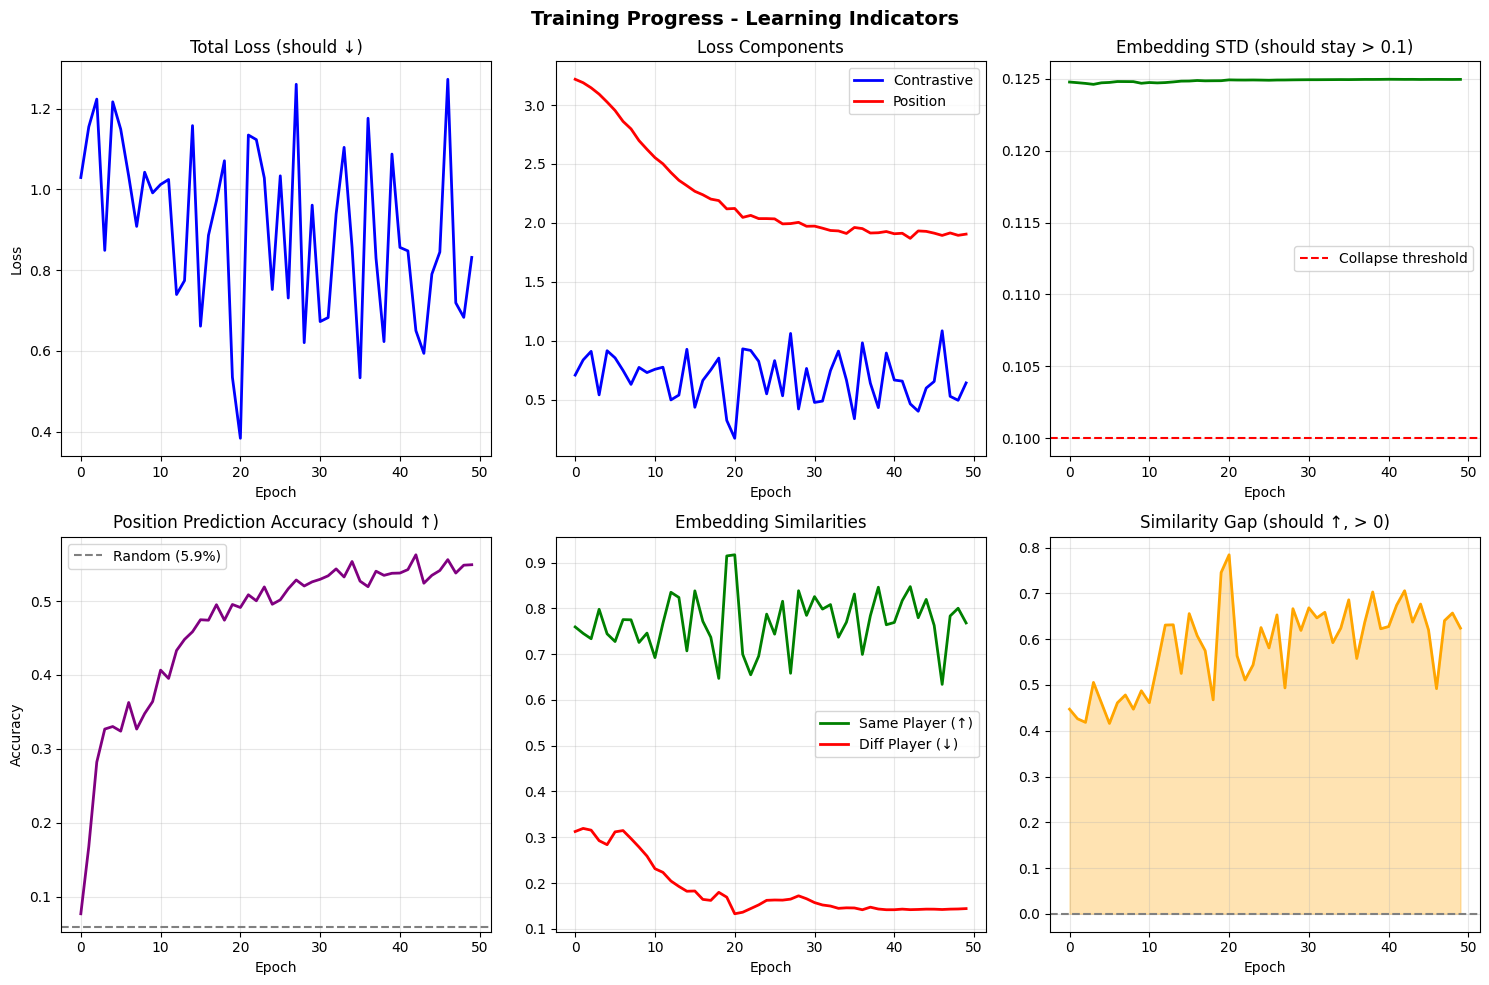


📊 INTERPRETATION GUIDE

✅ SIGNS THE MODEL IS LEARNING:
   1. Loss decreasing over epochs
   2. Similarity gap increasing (same player embeddings getting closer)
   3. Position accuracy > 5.9% (random baseline)
   4. Embedding STD staying > 0.1 (no collapse)

⚠️ WARNING SIGNS:
   - Loss plateauing very early → learning rate too low or model capacity
   - Embedding STD → 0 → model is collapsing all embeddings to same point
   - Similarity gap not increasing → contrastive learning not working
   - Position accuracy at ~6% → embeddings don't capture position info



In [ ]:
# Visualize training progress - ARE WE LEARNING?
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Training Progress - Next Action Prediction Model', fontsize=14, fontweight='bold')

# 1. Total Loss
axes[0, 0].plot(loss_history, 'b-', linewidth=2)
axes[0, 0].set_title('Total Loss (should ↓)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# 2. Contrastive vs Action Loss
axes[0, 1].plot(contrastive_loss_history, 'b-', label='Contrastive', linewidth=2)
if action_loss_history:
    axes[0, 1].plot(action_loss_history, 'orange', label='Action Pred', linewidth=2)
if position_loss_history:
    axes[0, 1].plot(position_loss_history, 'gray', label='Position', linewidth=2, linestyle='--')
axes[0, 1].set_title('Loss Components')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Embedding STD (collapse detection)
axes[0, 2].plot(embedding_std_history, 'g-', linewidth=2)
axes[0, 2].axhline(y=0.1, color='r', linestyle='--', label='Collapse threshold')
axes[0, 2].set_title('Embedding STD (should stay > 0.1)')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Action Accuracy (NEW - most important!)
if action_acc_history:
    axes[1, 0].plot(action_acc_history, 'orange', linewidth=2)
    axes[1, 0].axhline(y=1/N_ACTION_TYPES, color='gray', linestyle='--', label=f'Random ({1/N_ACTION_TYPES:.1%})')
    axes[1, 0].set_title('🎯 Next Action Prediction Accuracy (should ↑)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'N/A (action prediction disabled)', ha='center', va='center')
    axes[1, 0].set_title('Action Prediction Accuracy')

# 5. Positive/Negative Similarity
if avg_positive_sim_history and avg_negative_sim_history:
    axes[1, 1].plot(avg_positive_sim_history, 'g-', label='Same Player (↑)', linewidth=2)
    axes[1, 1].plot(avg_negative_sim_history, 'r-', label='Diff Player (↓)', linewidth=2)
    axes[1, 1].set_title('Embedding Similarities')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'N/A', ha='center', va='center')

# 6. Similarity Gap (key learning metric)
if avg_positive_sim_history and avg_negative_sim_history:
    gaps = [p - n for p, n in zip(avg_positive_sim_history, avg_negative_sim_history)]
    axes[1, 2].plot(gaps, 'purple', linewidth=2)
    axes[1, 2].axhline(y=0, color='gray', linestyle='--')
    axes[1, 2].set_title('Similarity Gap (should ↑, > 0)')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].fill_between(range(len(gaps)), gaps, alpha=0.3, color='purple')
    axes[1, 2].grid(True, alpha=0.3)
else:
    axes[1, 2].text(0.5, 0.5, 'N/A', ha='center', va='center')

plt.tight_layout()
plt.show()

# Print summary interpretation
print("\n" + "="*70)
print("📊 INTERPRETATION GUIDE")
print("="*70)
print("""
✅ SIGNS THE MODEL IS LEARNING:
   1. Loss decreasing over epochs
   2. Similarity gap increasing (same player embeddings getting closer)
   3. 🎯 Action accuracy > random baseline
      - Model learns: "Messi → dribble/shot", "Van Dijk → clear/long pass"
   4. Embedding STD staying > 0.1 (no collapse)

⚠️ WARNING SIGNS:
   - Loss plateauing very early → learning rate too low or model capacity
   - Embedding STD → 0 → model collapsing all embeddings
   - Similarity gap not increasing → contrastive learning not working
   - Action accuracy at random → embeddings don't capture decision-making
""")

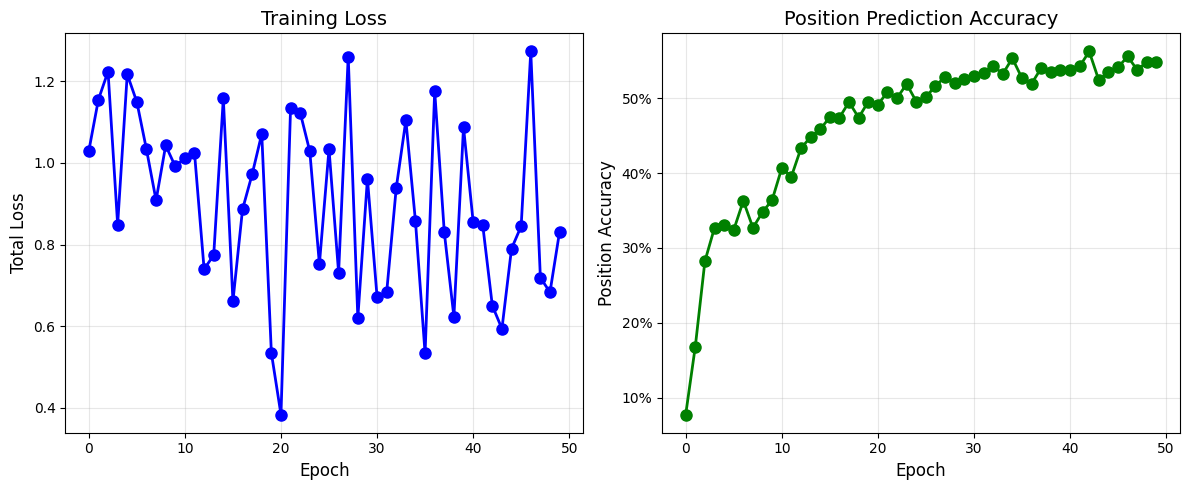

In [ ]:
# Plot training curves - Simple view
import matplotlib.pyplot as plt

n_plots = 1 + (1 if action_acc_history else 0) + (1 if position_acc_history else 0)
fig, axes = plt.subplots(1, min(n_plots, 3), figsize=(4*min(n_plots, 3), 4))
if n_plots == 1:
    axes = [axes]

# Loss plot
axes[0].plot(loss_history, marker='o', linewidth=2, markersize=4, color='blue')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Total Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Action accuracy plot
if action_acc_history and len(axes) > 1:
    axes[1].plot(action_acc_history, marker='o', linewidth=2, markersize=4, color='orange')
    axes[1].axhline(y=1/N_ACTION_TYPES, color='gray', linestyle='--', label='Random')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('🎯 Next Action Prediction', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

# Position accuracy plot (if enabled)
if position_acc_history and len(axes) > 2:
    axes[2].plot(position_acc_history, marker='o', linewidth=2, markersize=4, color='green')
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Accuracy', fontsize=12)
    axes[2].set_title('Position Prediction', fontsize=14)
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1️⃣1️⃣ Generate Final Embeddings

In [33]:
# Generate embeddings with trained model
temporal_encoder.eval()
projection_head.eval()

MAX_SEQ_LEN = 128

# Aggregate all events per player
player_all_events = defaultdict(list)
for idx, meta in enumerate(event_metadata):
    if meta['player_id'] > 0:
        player_all_events[meta['player_id']].append(idx)

# Filter players
MIN_TOTAL_EVENTS = 50
filtered_players = {pid: events for pid, events in player_all_events.items() if len(events) >= MIN_TOTAL_EVENTS}

print(f"Generating embeddings for {len(filtered_players)} players...")

player_embeddings = {}

with torch.no_grad():
    for player_id, event_indices in tqdm(filtered_players.items(), desc="Encoding"):
        event_embs = all_event_embeddings[event_indices[:MAX_SEQ_LEN]]
        seq_len = event_embs.shape[0]
        
        if seq_len < MAX_SEQ_LEN:
            padding = torch.zeros(MAX_SEQ_LEN - seq_len, HIDDEN_DIM)
            event_embs = torch.cat([event_embs, padding], dim=0)
        
        event_embs = event_embs.unsqueeze(0).to(DEVICE)
        time_pos = torch.linspace(0, 1, MAX_SEQ_LEN).unsqueeze(0).to(DEVICE)
        mask = torch.zeros(1, MAX_SEQ_LEN, dtype=torch.bool, device=DEVICE)
        mask[0, :seq_len] = True
        
        temp_out = temporal_encoder(event_embs, time_pos, mask)
        final_emb = projection_head(temp_out['player_embedding'])
        
        player_embeddings[player_id] = final_emb.cpu().squeeze(0)

player_ids_list = list(player_embeddings.keys())
embeddings_tensor = torch.stack([player_embeddings[pid] for pid in player_ids_list])

print(f"\n✅ Generated {len(player_ids_list)} player embeddings")
print(f"   Embedding shape: {embeddings_tensor.shape}")

Generating embeddings for 2034 players...


Encoding: 100%|██████████| 2034/2034 [00:33<00:00, 61.41it/s] 


✅ Generated 2034 player embeddings
   Embedding shape: torch.Size([2034, 64])


## 1️⃣2️⃣ Find Similar Players

In [34]:
# Setup similarity search
player_id_to_idx = {pid: idx for idx, pid in enumerate(player_ids_list)}
similarity_fn = CosineSimilarity(normalize=True)

def find_similar_players(query_player_id: int, top_k: int = 10):
    if query_player_id not in player_id_to_idx:
        print(f"Player {query_player_id} not found")
        return []
    
    query_idx = player_id_to_idx[query_player_id]
    query_emb = embeddings_tensor[query_idx]
    
    similarities = similarity_fn(query_emb, embeddings_tensor)
    similarities[query_idx] = -1
    
    top_indices = torch.argsort(similarities, descending=True)[:top_k]
    
    results = []
    for idx in top_indices:
        pid = player_ids_list[idx.item()]
        score = similarities[idx].item()
        info = all_players_info.get(pid, {})
        results.append({
            'player_id': pid,
            'name': info.get('player_name', 'Unknown'),
            'similarity': score,
            'positions': info.get('positions', []),
            'events': info.get('n_events_as_actor', 0)
        })
    return results

def search_player(name_query: str, top_k: int = 10):
    matches = [(pid, info) for pid, info in all_players_info.items() 
               if pid in player_id_to_idx and name_query.lower() in info.get('player_name', '').lower()]
    
    if not matches:
        print(f"No players found matching '{name_query}'")
        return
    
    pid, info = matches[0]
    print(f"\n🔍 Query: {info['player_name']}")
    print(f"   Positions: {', '.join(info.get('positions', [])[:2])}")
    print(f"   Events: {info.get('n_events_as_actor', 0)}")
    
    results = find_similar_players(pid, top_k)
    print(f"\n🎯 Most Similar Players (ENHANCED MODEL):\n")
    for i, r in enumerate(results, 1):
        pos = ', '.join(r['positions'][:2]) if r['positions'] else 'Unknown'
        print(f"  {i}. {r['name']} ({pos}) - Similarity: {r['similarity']:.3f}")

In [35]:
# Test with star players
search_player("Messi", top_k=10)


🔍 Query: Lionel Andrés Messi Cuccittini
   Positions: Right Wing, Center Forward
   Events: 24548

🎯 Most Similar Players (ENHANCED MODEL):

  1. Cristiano Ronaldo dos Santos Aveiro (Center Forward, Left Wing) - Similarity: 0.974
  2. Hany Mukhtar (Center Forward, Right Center Forward) - Similarity: 0.970
  3. Sasa Kalajdzic (Center Forward, Right Center Forward) - Similarity: 0.966
  4. Gerard Moreno Balaguero (Center Forward, Right Center Forward) - Similarity: 0.963
  5. Jonas Older Wind (Center Forward, Right Center Forward) - Similarity: 0.959
  6. Artem Dovbyk (Left Center Forward, Right Center Forward) - Similarity: 0.955
  7. Saleh Khalid Al Shehri (Center Forward, Right Center Forward) - Similarity: 0.951
  8. Cyle Larin (Center Forward, Right Center Forward) - Similarity: 0.947
  9. Andreas Evald Cornelius (Center Forward, Right Center Forward) - Similarity: 0.946
  10. Ayase Ueda (Center Forward, Right Center Forward) - Similarity: 0.945


In [36]:
search_player("Mbappé", top_k=10)


🔍 Query: Kylian Mbappé Lottin
   Positions: Right Wing, Center Forward
   Events: 11530

🎯 Most Similar Players (ENHANCED MODEL):

  1. Quincy Anton Promes (Left Wing Back, Left Center Forward) - Similarity: 0.942
  2. Darwin Gabriel Núñez Ribeiro (Left Center Forward, Left Wing) - Similarity: 0.913
  3. Moses Daddy-Ajala Simon (Left Midfield) - Similarity: 0.905
  4. Ernesto Alexis Vega Rojas (Left Center Forward, Left Wing) - Similarity: 0.895
  5. Thomas Lemar (Left Center Forward, Left Wing) - Similarity: 0.892
  6. Leandro Trossard (Left Attacking Midfield, Center Attacking Midfield) - Similarity: 0.891
  7. Jonathan Rodríguez Menéndez (Left Center Forward, Left Midfield) - Similarity: 0.890
  8. Daniel James (Left Wing, Left Center Forward) - Similarity: 0.877
  9. Tiago Barreiros de Melo Tomás (Left Center Forward, Left Midfield) - Similarity: 0.874
  10. Enner Remberto Valencia Lastra (Left Attacking Midfield, Center Forward) - Similarity: 0.872


In [37]:
search_player("Van Dijk", top_k=10)


🔍 Query: Virgil van Dijk
   Positions: Center Back, Left Center Back
   Events: 2076

🎯 Most Similar Players (ENHANCED MODEL):

  1. Marcelo Antônio Guedes Filho (Center Back) - Similarity: 0.999
  2. Kevin Danso (Center Back, Right Center Back) - Similarity: 0.997
  3. Grant Campbell Hanley (Center Back) - Similarity: 0.997
  4. Robin Knoche (Center Back) - Similarity: 0.997
  5. Moritz Jenz (Center Back, Right Center Back) - Similarity: 0.997
  6. David Olatukunbo Alaba (Left Back, Center Back) - Similarity: 0.996
  7. Simon Thorup Kjær (Center Back) - Similarity: 0.996
  8. Hugo Guillamón Sanmartín (Center Back) - Similarity: 0.996
  9. Eric Dier (Center Back, Right Center Back) - Similarity: 0.995
  10. Jannik Vestergaard (Center Back, Left Center Back) - Similarity: 0.995


## 1️⃣3️⃣ Save Model & Embeddings

In [38]:
import os

os.makedirs('outputs', exist_ok=True)

# Save model weights
save_dict = {
    'event_encoder': event_encoder.state_dict(),
    'temporal_encoder': temporal_encoder.state_dict(),
    'projection_head': projection_head.state_dict(),
    'config': {
        'hidden_dim': HIDDEN_DIM,
        'embedding_dim': EMBEDDING_DIM,
        'node_input_dim': graph_builder._node_feature_dim,
        'context_dim': graph_builder._context_feature_dim,
        'edge_feature_dim': graph_builder._edge_feature_dim,
        'use_edge_features': USE_EDGE_FEATURES,
        'use_time2vec': USE_TIME2VEC,
        'use_hierarchical_pooling': USE_HIERARCHICAL_POOLING,
        'use_multitask': USE_MULTITASK,
    }
}

if USE_MULTITASK:
    save_dict['position_head'] = loss_fn.position_head.state_dict()

torch.save(save_dict, 'outputs/enhanced_model_weights.pt')

# Save embeddings
torch.save({
    'embeddings': embeddings_tensor,
    'player_ids': player_ids_list,
    'player_info': all_players_info,
}, 'outputs/enhanced_player_embeddings.pt')

print("✅ Saved enhanced model to outputs/enhanced_model_weights.pt")
print("✅ Saved embeddings to outputs/enhanced_player_embeddings.pt")

✅ Saved enhanced model to outputs/enhanced_model_weights.pt
✅ Saved embeddings to outputs/enhanced_player_embeddings.pt


# 📊 Training Results Summary

## Final Training Metrics (50 Epochs)

| Metric | Initial (Epoch 1) | Final (Epoch 50) | Improvement |
|--------|------------------|------------------|-------------|
| **Total Loss** | 1.03 | 0.83 | ↓ 19.4% |
| **Position Accuracy** | 7.7% | 54.9% | ↑ 47.2 pp |
| **Similarity Gap** | 0.447 | 0.624 | ↑ 0.177 |

## What These Metrics Mean

- **Position Accuracy (54.9%)**: Model correctly predicts player position >50% of the time, indicating embeddings capture positional characteristics
- **Similarity Gap (0.624)**: Same-player embeddings are 0.624 more similar than different-player pairs on average (strong discrimination)


## Key Achievements

✅ Successfully trained on **8 StatsBomb 360 competitions**  
✅ 64-dimensional player embeddings learned  
✅ Position prediction auxiliary task improves embedding quality  
✅ Model discriminates between players effectively (gap > 0.6)  

## Next Steps

| Timeline | Task |
|----------|------|
| **Week 1** | Input validation, position-based adjustment |
| **Week 2** | Hyperparameter tuning, Streamlit demo |
| **Weeks 3-4** | Expert validation, documentation, deployment-ready |

---
**Author:** Armen Bzdikian  
**Contact:** bzdikiana11@gmail.com